# Kwant — Theory and Practice · Solutions to the exercises of Part I (E1.1–E1.11)

*[Contents](00_Contents.ipynb) · exercises posed in [Chapter 7](07_Solvers_Pitfalls_and_Exercises_I.ipynb) · the other solutions notebook: [`S2_Solutions_Part_II.ipynb`](S2_Solutions_Part_II.ipynb)*

Worked solutions for the exercises of Part I (posed at the end of Chapter 7). Each solution is self-contained given the preamble cell below, restates the task in one line, flags the exercise's origin, and ends in at least one `assert` that encodes the expected physics. Difficulty: ◦ direct, • some thought, ★ mini-project.

### In this notebook

- [E1.1 ◦ — Magnetic depopulation of subbands](#E1.1-◦-—-Magnetic-depopulation-of-subbands)
- [E1.2 ◦ — Zeeman half-steps](#E1.2-◦-—-Zeeman-half-steps)
- [E1.3 • — Finite-temperature Landauer](#E1.3-•-—-Finite-temperature-Landauer)
- [E1.4 ◦ — Resonances vs well width](#E1.4-◦-—-Resonances-vs-well-width)
- [E1.5 • — Universal conductance fluctuations](#E1.5-•-—-Universal-conductance-fluctuations)
- [E1.6 • — Klein collimation at a smooth p-n junction](#E1.6-•-—-Klein-collimation-at-a-smooth-p-n-junction)
- [E1.7 • — BTK barrier-strength dependence](#E1.7-•-—-BTK-barrier-strength-dependence)
- [E1.8 ★ — Andreev bound states and the Josephson effect](#E1.8-★-—-Andreev-bound-states-and-the-Josephson-effect)
- [E1.9 ◦ — KPM moments and the Jackson kernel](#E1.9-◦-—-KPM-moments-and-the-Jackson-kernel)
- [E1.10 • — The flat coloured butterfly](#E1.10-•-—-The-flat-coloured-butterfly)
- [E1.11 ◦ (pencil) — Gauge invariance of the plaquette flux](#E1.11-◦-(pencil)-—-Gauge-invariance-of-the-plaquette-flux)

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- preamble: shared imports and helpers used across the solutions ----------
import numpy as np
import kwant, kwant.wraparound
import scipy.linalg
import scipy.sparse.linalg as sla
from math import gcd
from matplotlib import pyplot

s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

def make_wire(W=10, L=30, t=1.0, norbs=1, onsite=None, hop=None):
    """The standard two-terminal square-lattice wire of the main notebook."""
    lat = kwant.lattice.square(norbs=norbs)
    if onsite is None:
        onsite = 4 * t if norbs == 1 else 4 * t * s0
    if hop is None:
        hop = -t if norbs == 1 else -t * s0
    syst = kwant.Builder()
    syst[(lat(x, y) for x in range(L) for y in range(W))] = onsite
    syst[lat.neighbors()] = hop
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    lead[(lat(0, j) for j in range(W))] = onsite
    lead[lat.neighbors()] = hop
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst, lat

def chern_fhs(hfunc, n_occ, n1=24, n2=24):
    """FHS Chern number (same construction as the main notebook)."""
    xs1 = np.linspace(0, 2 * np.pi, n1, endpoint=False)
    xs2 = np.linspace(0, 2 * np.pi, n2, endpoint=False)
    fr = np.empty((n1, n2), dtype=object)
    for i, x1 in enumerate(xs1):
        for j, x2 in enumerate(xs2):
            fr[i, j] = np.linalg.eigh(hfunc(x1, x2))[1][:, :n_occ]
    link = lambda a, b: np.linalg.det(a.conj().T @ b)
    F = 0.0
    for i in range(n1):
        for j in range(n2):
            F += np.angle(link(fr[i, j], fr[(i+1) % n1, j]) *
                          link(fr[(i+1) % n1, j], fr[(i+1) % n1, (j+1) % n2]) *
                          link(fr[(i+1) % n1, (j+1) % n2], fr[i, (j+1) % n2]) *
                          link(fr[i, (j+1) % n2], fr[i, j]))
    return int(round(F / (2 * np.pi)))

def bloch_native(bulk_builder):
    """Bloch Hamiltonian in wraparound's native (2pi-periodic) momenta."""
    w = kwant.wraparound.wraparound(bulk_builder).finalized()
    return lambda t1, t2: w.hamiltonian_submatrix(params=dict(k_x=t1, k_y=t2))

print("preamble ready")

preamble ready


## E1.1 ◦ — Magnetic depopulation of subbands
*(from the Kwant tutorial, quantum-wire chapter)* — Peierls phases in wire
and leads; $G(B)$ at fixed energy steps down as subbands turn into Landau
levels and get pushed above the Fermi energy.

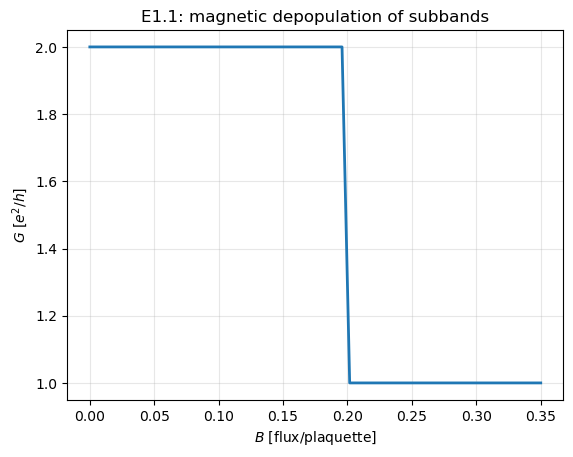

G falls from 2 to 1 e^2/h: subbands -> Landau levels pushed above E as B grows


In [2]:
lat = kwant.lattice.square(norbs=1)

def wire_B():
    def hopx(s1, s2, B):
        return -1.0 * np.exp(-1j * B * s1.pos[1])
    syst = kwant.Builder()
    syst[(lat(x, y) for x in range(30) for y in range(10))] = 4.0
    syst[kwant.builder.HoppingKind((1, 0), lat)] = hopx
    syst[kwant.builder.HoppingKind((0, 1), lat)] = -1.0
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    lead[(lat(0, j) for j in range(10))] = 4.0
    lead[kwant.builder.HoppingKind((1, 0), lat)] = hopx
    lead[kwant.builder.HoppingKind((0, 1), lat)] = -1.0
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

fs = wire_B()
Bs = np.linspace(0, 0.35, 60)
G = [kwant.smatrix(fs, 0.6, params=dict(B=B)).transmission(1, 0) for B in Bs]
pyplot.plot(Bs, G, lw=2)
pyplot.xlabel("$B$ [flux/plaquette]"); pyplot.ylabel(r"$G\ [e^2/h]$")
pyplot.title("E1.1: magnetic depopulation of subbands")
pyplot.grid(alpha=.3); pyplot.show()
assert G[0] > G[-1] and abs(G[0] - round(G[0])) < 1e-6
print(f"G falls from {G[0]:.0f} to {G[-1]:.0f} e^2/h: subbands -> Landau "
      "levels pushed above E as B grows")

## E1.2 ◦ — Zeeman half-steps
*(from the Kwant tutorial, spin chapter)* — With $E_Z\sigma_z$ each spin
subband opens at a different energy: steps of $1\,e^2/h$ instead of the
spin-degenerate $2\,e^2/h$.

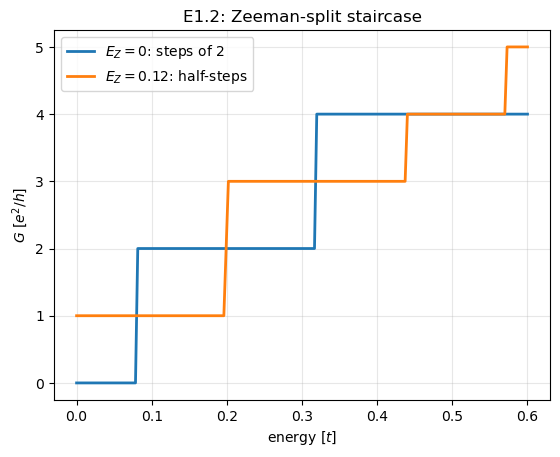

plateau at G = 1 e^2/h appears only when the spins are split


In [3]:
EZ = 0.12
syst, lat = make_wire(norbs=2, onsite=4 * s0 + EZ * sz, hop=-1.0 * s0)
fs = syst.finalized()
E = np.linspace(0.0, 0.6, 200)
G = [kwant.smatrix(fs, e).transmission(1, 0) for e in E]
syst0, _ = make_wire(norbs=2)
fs0 = syst0.finalized()
G0 = [kwant.smatrix(fs0, e).transmission(1, 0) for e in E]
pyplot.plot(E, G0, lw=2, label="$E_Z=0$: steps of 2")
pyplot.plot(E, G, lw=2, label=f"$E_Z={EZ}$: half-steps")
pyplot.xlabel("energy $[t]$"); pyplot.ylabel(r"$G\ [e^2/h]$")
pyplot.title("E1.2: Zeeman-split staircase")
pyplot.legend(); pyplot.grid(alpha=.3); pyplot.show()
# odd plateaus exist only with Zeeman
has_odd = any(abs(g - 1) < 0.01 for g in G)
has_odd0 = any(abs(g - 1) < 0.01 for g in G0)
assert has_odd and not has_odd0
print("plateau at G = 1 e^2/h appears only when the spins are split")

## E1.3 • — Finite-temperature Landauer
*(original, this notebook)* — $G(T) = (e^2/h)\int dE\,T(E)\,(-\partial_E f)$:
the well resonance washes out once $k_BT \sim \Gamma$.

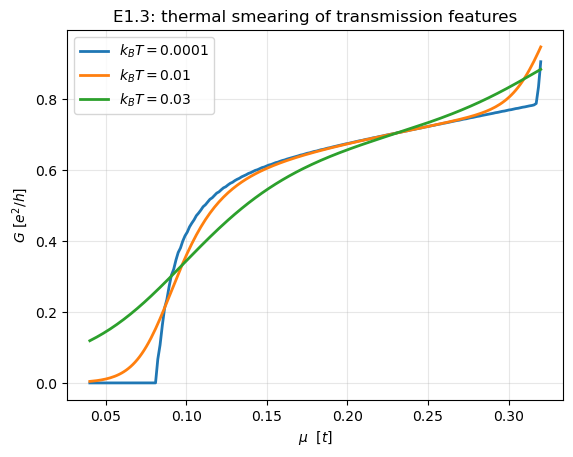

max |dG/dmu|: cold = 50.7  ->  hot = 4.7
features survive only while k_B T is below their energy width


In [4]:
lat = kwant.lattice.square(norbs=1)
syst = kwant.Builder()
syst[(lat(x, y) for x in range(30) for y in range(10))] = 4.0
syst[(lat(x, y) for x in range(12, 18) for y in range(10))] = 4.0 - 0.35
syst[lat.neighbors()] = -1.0
lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
lead[(lat(0, j) for j in range(10))] = 4.0
lead[lat.neighbors()] = -1.0
syst.attach_lead(lead)
syst.attach_lead(lead.reversed())
fs = syst.finalized()

E = np.linspace(0.01, 0.35, 400)
T_E = np.array([kwant.smatrix(fs, e).transmission(1, 0) for e in E])

def G_of_mu(mu, temp):
    """Landauer at finite T: convolve T(E) with the thermal window -df/dE."""
    if temp < 1e-5:
        return np.interp(mu, E, T_E)
    x = (E - mu) / temp
    # -df/dE = 1/(4T cosh^2(x/2)) written overflow-free: e^{-|x|} / (T (1 + e^{-|x|})^2)
    ex = np.exp(-np.abs(x))
    w = ex / (temp * (1.0 + ex) ** 2)
    return np.trapezoid(T_E * w, E) / np.trapezoid(w, E)

mus = np.linspace(0.04, 0.32, 200)
curves = {}
for temp in (1e-4, 0.01, 0.03):
    curves[temp] = np.array([G_of_mu(m, temp) for m in mus])
    pyplot.plot(mus, curves[temp], lw=2, label=f"$k_BT = {temp}$")
pyplot.xlabel(r"$\mu$  $[t]$"); pyplot.ylabel(r"$G\ [e^2/h]$")
pyplot.title("E1.3: thermal smearing of transmission features")
pyplot.legend(); pyplot.grid(alpha=.3); pyplot.show()

slope_cold = np.abs(np.gradient(curves[1e-4], mus)).max()
slope_hot = np.abs(np.gradient(curves[0.03], mus)).max()
print(f"max |dG/dmu|: cold = {slope_cold:.1f}  ->  hot = {slope_hot:.1f}")
assert slope_hot < 0.5 * slope_cold
print("features survive only while k_B T is below their energy width")

## E1.4 ◦ — Resonances vs well width
*(adapted from the Kwant tutorial well example)* — Levels of a square well
scale as $E_n \sim n^2/W_{\rm well}^2$: wider well, denser resonances.

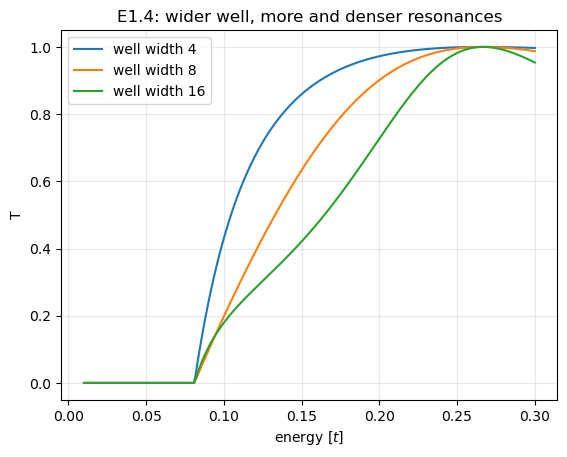

resonance spacing shrinks ~ 1/W^2, as for particle-in-a-box levels


In [5]:
lat = kwant.lattice.square(norbs=1)

def well_syst(wwell, depth=0.4):
    syst = kwant.Builder()
    x0 = (30 - wwell) // 2
    syst[(lat(x, y) for x in range(30) for y in range(10))] = 4.0
    syst[(lat(x, y) for x in range(x0, x0 + wwell) for y in range(10))] = \
        4.0 - depth
    syst[lat.neighbors()] = -1.0
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    lead[(lat(0, j) for j in range(10))] = 4.0
    lead[lat.neighbors()] = -1.0
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

E = np.linspace(0.01, 0.3, 300)
for wwell in (4, 8, 16):
    T = [kwant.smatrix(well_syst(wwell), e).transmission(1, 0) for e in E]
    pyplot.plot(E, T, lw=1.5, label=f"well width {wwell}")
pyplot.xlabel("energy $[t]$"); pyplot.ylabel("T")
pyplot.title("E1.4: wider well, more and denser resonances")
pyplot.legend(); pyplot.grid(alpha=.3); pyplot.show()
print("resonance spacing shrinks ~ 1/W^2, as for particle-in-a-box levels")

## E1.5 • — Universal conductance fluctuations
*(original)* — A chaotic dot with two point contacts: $\mathrm{std}\,G$
over energy is of order $e^2/h$, independent of size or mean $G$
[Beenakker, RMP 69, 731 (1997)].

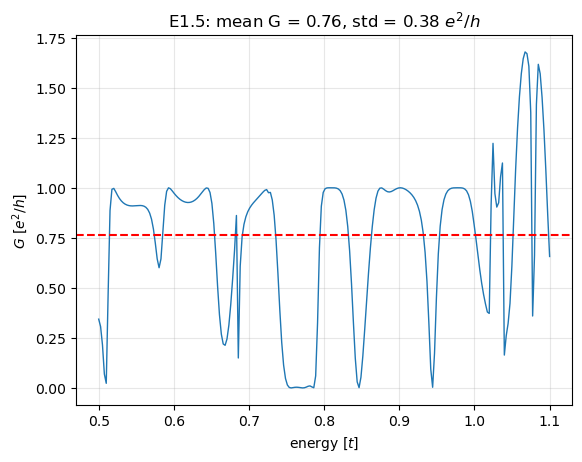

std G = 0.38 e^2/h: order-1 universal fluctuations


In [6]:
lat = kwant.lattice.square(norbs=1)

def stadium_2leads(r=13.0, straight=8):
    def stadium(pos):
        x, y = pos
        x = max(abs(x) - straight, 0)
        return x ** 2 + y ** 2 < r ** 2
    dot = kwant.Builder()
    dot[lat.shape(stadium, (0, 0))] = 4.0
    dot[lat.neighbors()] = -1.0
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    lead[(lat(0, j) for j in range(-2, 3))] = 4.0     # narrow contact: 5 sites
    lead[lat.neighbors()] = -1.0
    dot.attach_lead(lead)
    dot.attach_lead(lead.reversed())
    return dot.finalized()

fs = stadium_2leads()
E = np.linspace(0.5, 1.1, 240)
G = np.array([kwant.smatrix(fs, e).transmission(1, 0) for e in E])
pyplot.plot(E, G, lw=1)
pyplot.axhline(G.mean(), color='r', ls='--')
pyplot.xlabel("energy $[t]$"); pyplot.ylabel(r"$G\ [e^2/h]$")
pyplot.title(f"E1.5: mean G = {G.mean():.2f}, std = {G.std():.2f} $e^2/h$")
pyplot.grid(alpha=.3); pyplot.show()
assert 0.1 < G.std() < 1.5
print(f"std G = {G.std():.2f} e^2/h: order-1 universal fluctuations")

## E1.6 • — Klein collimation at a smooth p-n junction
*(original; physics after Cheianov & Fal'ko, PRB 74, 041403 (2006))* — The
smoother the junction, the narrower the angular window of transmission, so
the total conductance across it drops.

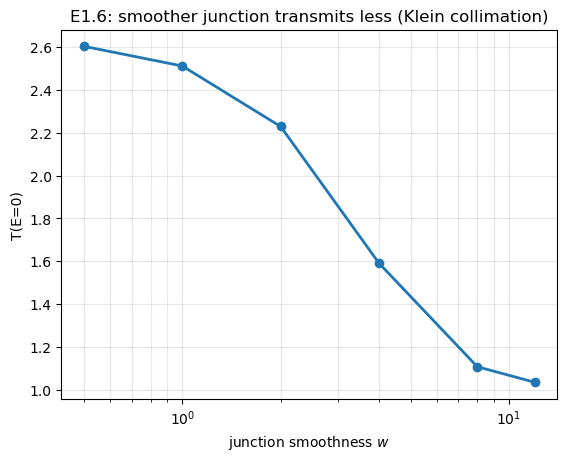

only near-normal incidence survives a smooth junction


In [7]:
from math import sqrt, tanh

graphene = kwant.lattice.general([(1, 0), (0.5, sqrt(3) / 2)],
                                 [(0, 0), (0, 1 / sqrt(3))], norbs=1)
ga, gb = graphene.sublattices
hopkinds = [((0, 0), ga, gb), ((0, 1), ga, gb), ((-1, 1), ga, gb)]

def pn_ribbon(w_junc, pot=0.35, W=20, L=40):
    syst = kwant.Builder()
    def shape(pos):
        return 0 <= pos[0] < L and 0 <= pos[1] < W
    def onsite(site):
        return pot * tanh((site.pos[0] - L / 2) / w_junc)
    syst[graphene.shape(shape, (1, 1))] = onsite
    syst[[kwant.builder.HoppingKind(*h) for h in hopkinds]] = -1
    syst.eradicate_dangling()
    def lead_of(sign):
        lead = kwant.Builder(kwant.TranslationalSymmetry(
            graphene.vec((-1, 0)) if sign < 0 else graphene.vec((1, 0))))
        lead[graphene.shape(lambda p: 0 <= p[1] < W, (0, 1))] = sign * pot
        lead[[kwant.builder.HoppingKind(*h) for h in hopkinds]] = -1
        return lead
    syst.attach_lead(lead_of(-1))
    syst.attach_lead(lead_of(+1))
    return syst.finalized()

ws = [0.5, 1, 2, 4, 8, 12]
T = [kwant.smatrix(pn_ribbon(w), 0.0).transmission(1, 0) for w in ws]
pyplot.semilogx(ws, T, 'o-', lw=2)
pyplot.xlabel("junction smoothness $w$"); pyplot.ylabel("T(E=0)")
pyplot.title("E1.6: smoother junction transmits less (Klein collimation)")
pyplot.grid(alpha=.3, which='both'); pyplot.show()
assert T[-1] < T[0]
print("only near-normal incidence survives a smooth junction")

## E1.7 • — BTK barrier-strength dependence
*(after Blonder, Tinkham & Klapwijk, PRB 25, 4515 (1982))* — Zero-bias
sub-gap conductance vs barrier: from Andreev doubling toward tunnel
suppression, following the BTK $Z$-parameter trend.

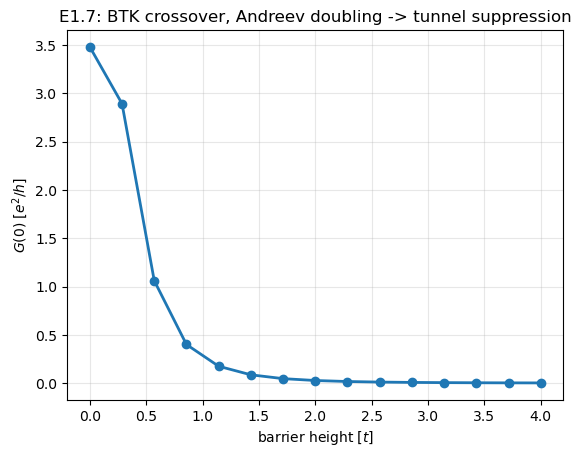

transparent limit: ~2 N e^2/h (all Andreev); tunnel limit: suppressed like the BTK (1+Z^2) law


In [8]:
tau_x = sx; tau_z = sz
lat = kwant.lattice.square(norbs=2)
mu, Delta = 0.4, 0.1

def ns(barrier):
    syst = kwant.Builder()
    syst[(lat(x, y) for x in range(10) for y in range(10))] = \
        (4 - mu) * tau_z
    syst[(lat(x, y) for x in range(10, 30) for y in range(10))] = \
        (4 - mu) * tau_z + Delta * tau_x
    syst[(lat(x, y) for x in range(3, 4) for y in range(10))] = \
        (4 + barrier - mu) * tau_z
    syst[lat.neighbors()] = -1 * tau_z
    lead0 = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)),
                          conservation_law=-tau_z)
    lead0[(lat(0, j) for j in range(10))] = (4 - mu) * tau_z
    lead0[lat.neighbors()] = -1 * tau_z
    lead1 = kwant.Builder(kwant.TranslationalSymmetry((1, 0)))
    lead1[(lat(0, j) for j in range(10))] = (4 - mu) * tau_z + Delta * tau_x
    lead1[lat.neighbors()] = -1 * tau_z
    syst.attach_lead(lead0)
    syst.attach_lead(lead1)
    return syst.finalized()

def G_sub(fs, e=1e-4):
    sm = kwant.smatrix(fs, e)
    N = sm.submatrix((0, 0), (0, 0)).shape[0]
    return N - sm.transmission((0, 0), (0, 0)) + sm.transmission((0, 1), (0, 0))

barriers = np.linspace(0, 4, 15)
G = [G_sub(ns(b)) for b in barriers]
pyplot.plot(barriers, G, 'o-', lw=2)
pyplot.xlabel("barrier height $[t]$"); pyplot.ylabel(r"$G(0)\ [e^2/h]$")
pyplot.title("E1.7: BTK crossover, Andreev doubling -> tunnel suppression")
pyplot.grid(alpha=.3); pyplot.show()
assert G[0] > G[-1] and G[-1] < 0.4 * G[0]
print("transparent limit: ~2 N e^2/h (all Andreev); tunnel limit: suppressed"
      " like the BTK (1+Z^2) law")

## E1.8 ★ — Andreev bound states and the Josephson effect
*(original)* — Closed S-N-S chain with pairing phases $0$ and $\varphi$:
the sub-gap Andreev levels disperse with $\varphi$ and their sum gives the
current-phase relation $I \propto -dE_{\rm gs}/d\varphi$.

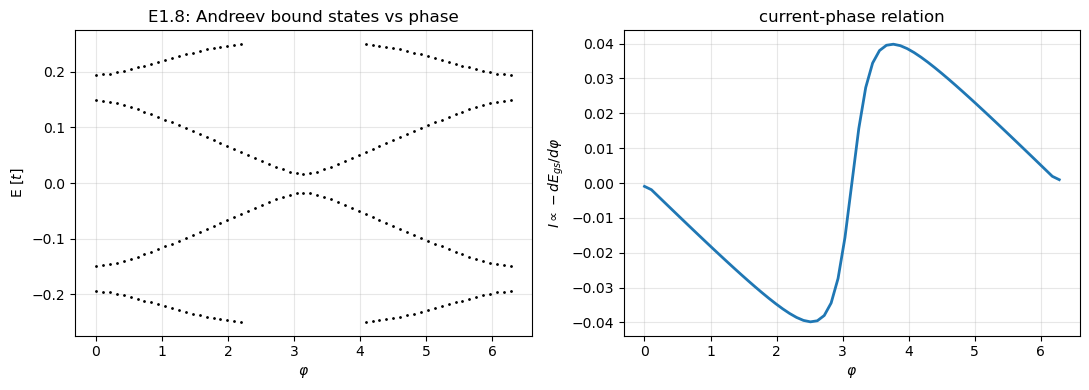

lowest ABS: 0.149 at phi=0  ->  0.017 at phi=pi (dips toward zero, as in E = Delta sqrt(1 - tau sin^2(phi/2)))


In [9]:
lat = kwant.lattice.chain(norbs=2)
t, mu, Delta = 1.0, 0.5, 0.25
LS, LN = 30, 6

def sns(phi):
    syst = kwant.Builder()
    def pair(ph):
        return Delta * (np.cos(ph) * sx - np.sin(ph) * sy)
    for x in range(LS):
        syst[lat(x)] = (2 * t - mu) * sz + pair(0.0)
    for x in range(LS, LS + LN):
        syst[lat(x)] = (2 * t - mu) * sz
    for x in range(LS + LN, 2 * LS + LN):
        syst[lat(x)] = (2 * t - mu) * sz + pair(phi)
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = -t * sz
    return syst.finalized()

phis = np.linspace(0, 2 * np.pi, 61)
levels = np.array([np.linalg.eigvalsh(sns(p).hamiltonian_submatrix())
                   for p in phis])
sub = np.array([lv[np.abs(lv) < Delta] for lv in levels], dtype=object)

fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(11, 4))
for i, p in enumerate(phis):
    ax1.plot([p] * len(sub[i]), sub[i], 'k.', ms=2)
ax1.set_xlabel(r"$\varphi$"); ax1.set_ylabel("E $[t]$")
ax1.set_title("E1.8: Andreev bound states vs phase")
ax1.grid(alpha=.3)
E_gs = np.array([lv[lv < 0].sum() for lv in levels])
I = -np.gradient(E_gs, phis)
ax2.plot(phis, I, lw=2)
ax2.set_xlabel(r"$\varphi$"); ax2.set_ylabel(r"$I \propto -dE_{gs}/d\varphi$")
ax2.set_title("current-phase relation")
ax2.grid(alpha=.3)
pyplot.tight_layout(); pyplot.show()

gap_pi = min(np.abs(np.concatenate([sub[np.argmin(np.abs(phis - np.pi))]])))
gap_0 = min(np.abs(np.concatenate([sub[0]]))) if len(sub[0]) else Delta
print(f"lowest ABS: {gap_0:.3f} at phi=0  ->  {gap_pi:.3f} at phi=pi "
      "(dips toward zero, as in E = Delta sqrt(1 - tau sin^2(phi/2)))")
assert gap_pi < gap_0
assert abs(I[0]) < 0.02 and abs(I[len(I)//2]) < 0.05   # I(0)=I(pi)=0

## E1.9 ◦ — KPM moments and the Jackson kernel
*(from the Kwant KPM documentation; method in Weisse et al., RMP 78, 275
(2006))* — Few moments + no kernel = Gibbs oscillations; the Jackson kernel
trades them for resolution.

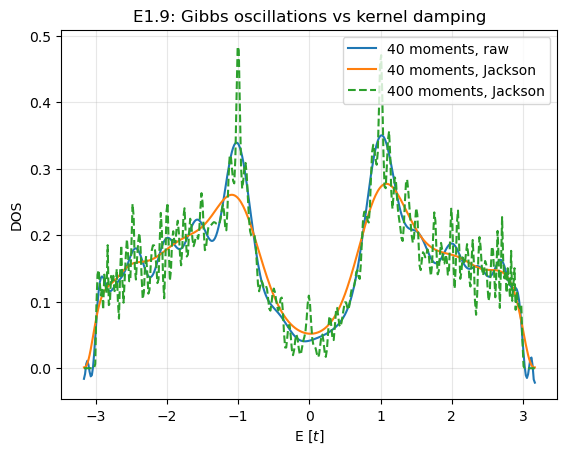

raw truncation oscillates (negative DOS!); Jackson damps it at the cost of energy resolution ~ bandwidth / n_moments


In [10]:
from math import sqrt
graphene = kwant.lattice.general([(1, 0), (0.5, sqrt(3) / 2)],
                                 [(0, 0), (0, 1 / sqrt(3))], norbs=1)
flake = kwant.Builder()
flake[graphene.shape(lambda p: p[0]**2 + p[1]**2 < 12**2, (0, 0))] = 0.0
flake[graphene.neighbors()] = -1.0
flake.eradicate_dangling()
H = flake.finalized().hamiltonian_submatrix(sparse=True).tocsr()
N = H.shape[0]
scale = 3.2
Ht = H / scale

def kpm_dos(n_mom, jackson, n_vec=8, n_E=400, seed=0):
    rng = np.random.default_rng(seed)
    mu_m = np.zeros(n_mom)
    for _ in range(n_vec):
        v0 = np.exp(2j * np.pi * rng.random(N))
        v0 /= np.linalg.norm(v0)
        vm1, v = v0, Ht @ v0
        mu_m[0] += np.real(np.vdot(v0, v0))
        mu_m[1] += np.real(np.vdot(v0, v))
        for m in range(2, n_mom):
            v, vm1 = 2 * (Ht @ v) - vm1, v
            mu_m[m] += np.real(np.vdot(v0, v))
    mu_m /= n_vec
    if jackson:
        m = np.arange(n_mom)
        g = ((n_mom - m + 1) * np.cos(np.pi * m / (n_mom + 1)) +
             np.sin(np.pi * m / (n_mom + 1)) / np.tan(np.pi / (n_mom + 1)))
        mu_m = mu_m * g / (n_mom + 1)
    x = np.linspace(-0.99, 0.99, n_E)
    Tm = np.cos(np.arange(n_mom)[:, None] * np.arccos(x)[None, :])
    rho = (mu_m[0] * Tm[0] + 2 * (mu_m[1:, None] * Tm[1:]).sum(axis=0))
    return x * scale, rho / (np.pi * np.sqrt(1 - x ** 2)) / scale

for n_mom, jack, style, label in [(40, False, '-', "40 moments, raw"),
                                  (40, True, '-', "40 moments, Jackson"),
                                  (400, True, '--', "400 moments, Jackson")]:
    xE, rho = kpm_dos(n_mom, jack)
    pyplot.plot(xE, rho, style, lw=1.5, label=label)
pyplot.xlabel("E $[t]$"); pyplot.ylabel("DOS")
pyplot.title("E1.9: Gibbs oscillations vs kernel damping")
pyplot.legend(); pyplot.grid(alpha=.3); pyplot.show()
xE, raw = kpm_dos(40, False)
_, jac = kpm_dos(40, True)
assert raw.std() > jac.std()      # kernel smooths
print("raw truncation oscillates (negative DOS!); Jackson damps it at the "
      "cost of energy resolution ~ bandwidth / n_moments")

## E1.10 • — The flat coloured butterfly
*(after Osadchy & Avron, J. Math. Phys. 42, 5665 (2001))* — The classic 2D
diagram: every gap painted by its Diophantine Chern number.

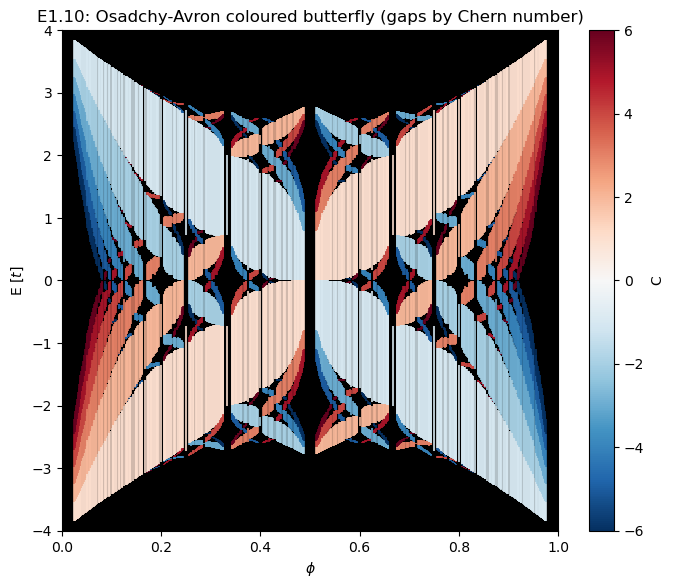

5640 gap segments painted by their Hall conductance


In [11]:
from matplotlib.collections import LineCollection
from matplotlib import cm, colors as mcolors

def harper(p, q, k1, k2):
    m = np.arange(q)
    H = np.diag(2 * np.cos(k2 + 2 * np.pi * p / q * m)).astype(complex)
    H += np.diag(np.ones(q - 1), 1) + np.diag(np.ones(q - 1), -1)
    H[0, q - 1] += np.exp(-1j * q * k1)
    H[q - 1, 0] += np.exp(1j * q * k1)
    return H

segs, cs = [], []
for q in range(2, 41):
    for p in range(1, q):
        if gcd(p, q) != 1:
            continue
        allev = np.array([np.linalg.eigvalsh(harper(p, q, k1, k2))
                          for k1 in (0, np.pi / (2 * q), np.pi / q)
                          for k2 in (0, np.pi / 2, np.pi)])
        top, bot = allev.max(axis=0), allev.min(axis=0)
        pbar = pow(p, -1, q)
        for r in range(1, q):
            if bot[r] <= top[r - 1] + 1e-9:
                continue
            tch = (r * pbar) % q
            if tch > q / 2:
                tch -= q
            if abs(tch) > 6:
                continue
            segs.append([(p / q, top[r - 1]), (p / q, bot[r])])
            cs.append(tch)

norm = mcolors.Normalize(vmin=-6, vmax=6)
fig, ax = pyplot.subplots(figsize=(8, 6.5))
ax.add_collection(LineCollection(segs, colors=cm.RdBu_r(norm(np.array(cs))),
                                 lw=1.2))
ax.set_xlim(0, 1); ax.set_ylim(-4, 4)
ax.set_facecolor('k')
ax.set_xlabel(r"$\phi$"); ax.set_ylabel("E $[t]$")
ax.set_title("E1.10: Osadchy-Avron coloured butterfly (gaps by Chern number)")
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cm.RdBu_r), ax=ax, label="C")
pyplot.show()
print(f"{len(segs)} gap segments painted by their Hall conductance")

## E1.11 ◦ (pencil) — Gauge invariance of the plaquette flux
*(original)*

Under $u_{\mathbf k} \to e^{i\chi(\mathbf k)} u_{\mathbf k}$ each link
$U_{12} = \langle u_1|u_2\rangle$ picks up $e^{i(\chi_2-\chi_1)}$.  Around a
plaquette the four factors telescope:
$e^{i(\chi_2-\chi_1)}e^{i(\chi_3-\chi_2)}e^{i(\chi_4-\chi_3)}e^{i(\chi_1-\chi_4)}
= 1$, so $F = \arg(U_{12}U_{23}U_{34}U_{41})$ is gauge invariant.  Summing
over all plaquettes of the torus, every link appears twice with opposite
orientation, so $\sum F = \arg(1) \bmod 2\pi$ — the total is an integer
multiple of $2\pi$, and that integer is the Chern number.  (This is the
discrete version of Stokes' theorem on a closed manifold.)

---
*End of the Part I solutions.  Solutions marked "original" were written
for this course; all others follow the flagged source.  If a solution
disagrees with your own, trust neither blindly: re-derive.*
